In [1]:
!pip install ucimlrepo

Defaulting to user installation because normal site-packages is not writeable


## dibites from cdc

In [2]:
import pandas as pd
import numpy as np
import os
import json
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from mpl_toolkits.mplot3d import Axes3D
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, RocCurveDisplay
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV

In [3]:

#this section from cdc website on how to import there data

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
x = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

# metadata
#print(cdc_diabetes_health_indicators.metadata)

# variable information
#print(cdc_diabetes_health_indicators.variables)


In [4]:
cdc_diabetes_health_indicators.metadata

{'uci_id': 891,
 'name': 'CDC Diabetes Health Indicators',
 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators',
 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv',
 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ',
 'area': 'Health and Medicine',
 'tasks': ['Classification'],
 'characteristics': ['Tabular', 'Multivariate'],
 'num_instances': 253680,
 'num_features': 21,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Sex', 'Age', 'Education Level', 'Income'],
 'target_col': ['Diabetes_binary'],
 'index_col': ['ID'],
 'has_missing_values': 'no',
 'missing_values_symbol

In [5]:
cdc_diabetes_health_indicators.variables

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,None,Patient ID,None,no
1,Diabetes_binary,Target,Binary,None,0 = no diabetes 1 = prediabetes or diabetes,None,no
2,HighBP,Feature,Binary,None,0 = no high BP 1 = high BP,None,no
3,HighChol,Feature,Binary,None,0 = no high cholesterol 1 = high cholesterol,None,no
4,CholCheck,Feature,Binary,None,0 = no cholesterol check in 5 years 1 = yes ch...,None,no
5,BMI,Feature,Integer,None,Body Mass Index,None,no
6,Smoker,Feature,Binary,None,Have you smoked at least 100 cigarettes in you...,None,no
7,Stroke,Feature,Binary,None,(Ever told) you had a stroke. 0 = no 1 = yes,None,no
8,HeartDiseaseorAttack,Feature,Binary,None,coronary heart disease (CHD) or myocardial inf...,None,no
9,PhysActivity,Feature,Binary,None,physical activity in past 30 days - not includ...,None,no


In [6]:
# Combine features (X) and target (y) into one DataFrame
df = pd.concat([x, y], axis=1)

In [7]:
df.columns

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'Diabetes_binary'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-n

In [14]:
df.isnull().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

no missing data

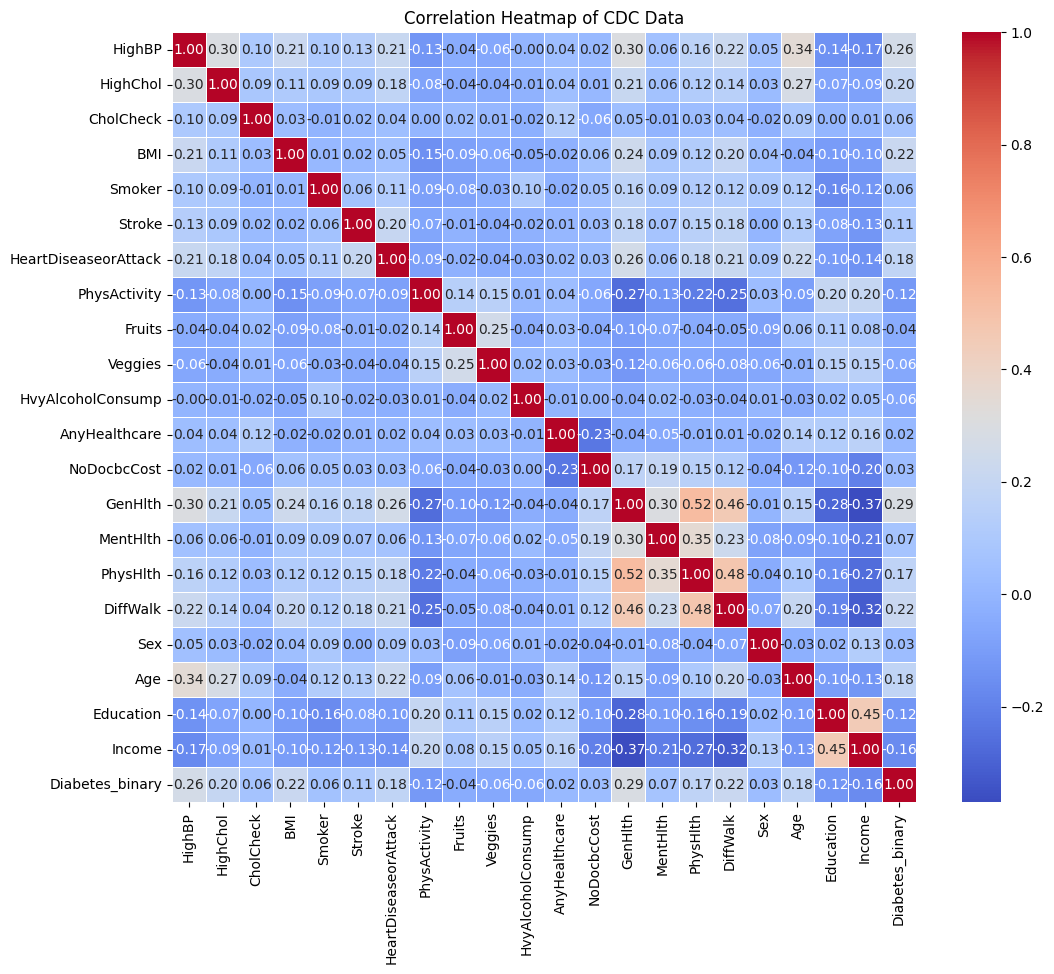

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of CDC Data')
plt.show()


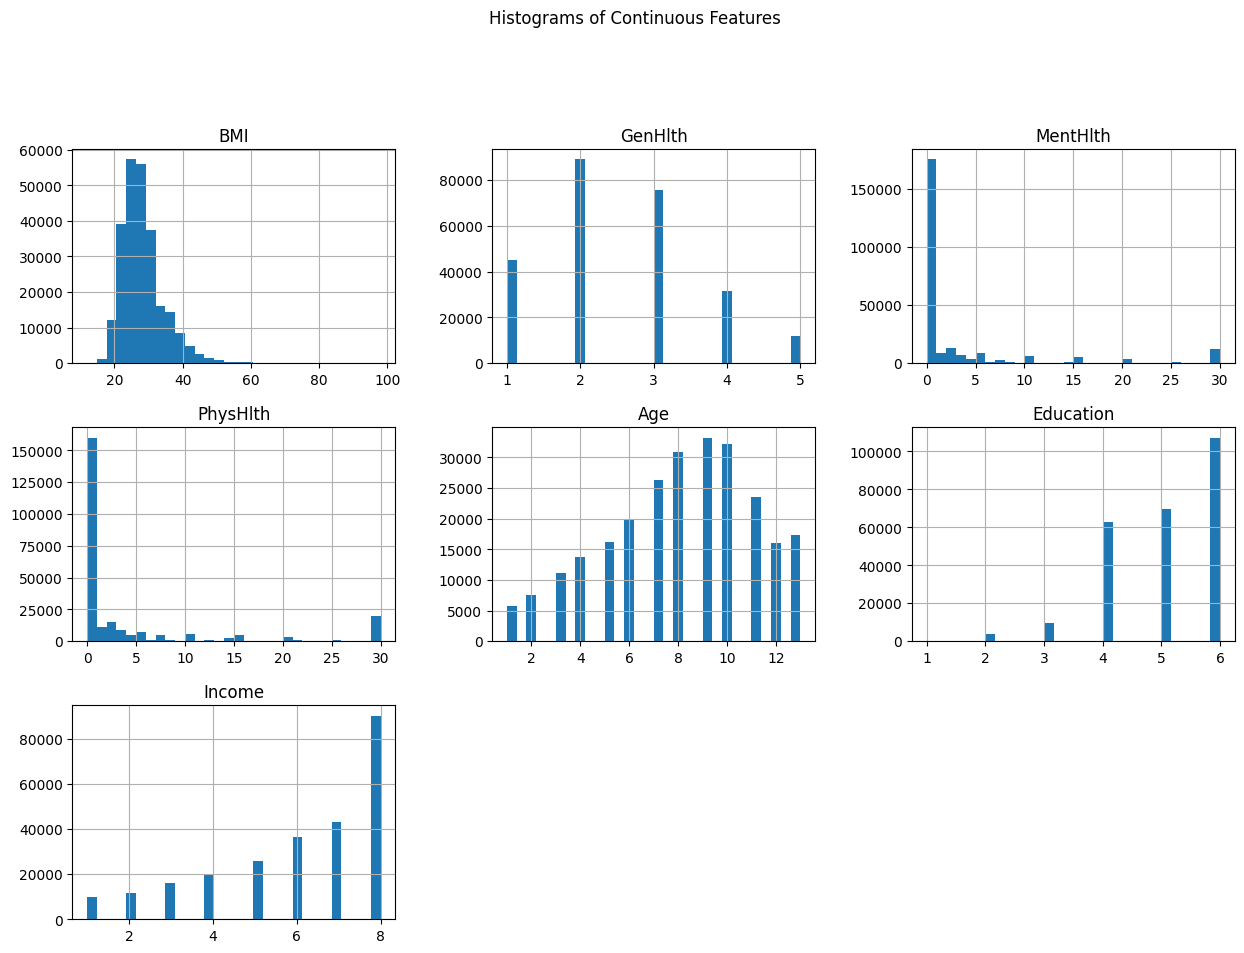

In [10]:
continuous_cols = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

df[continuous_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle("Histograms of Continuous Features", y=1.02)
plt.show()


these graph show the demografic and the tells us about the people,they are in higher bracket mostly , with good physical health and mental health, in middle ages
and had decent education but the data is of 23k people that means there ware enough entries in each sub columns

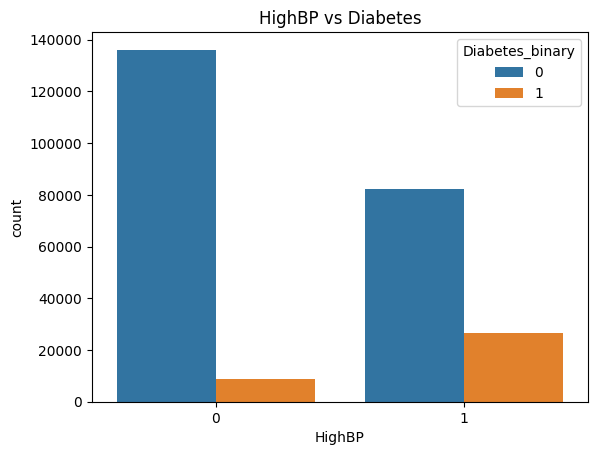

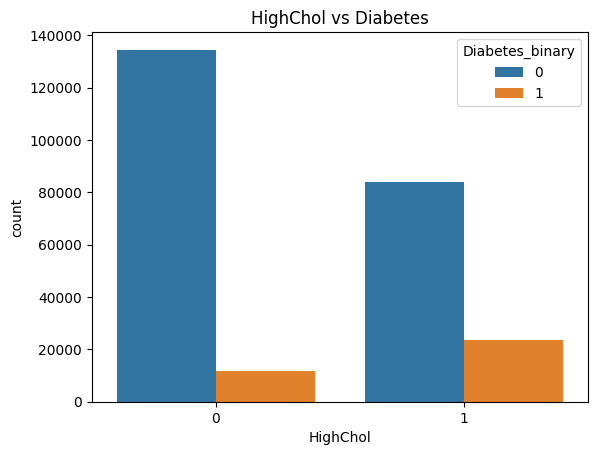

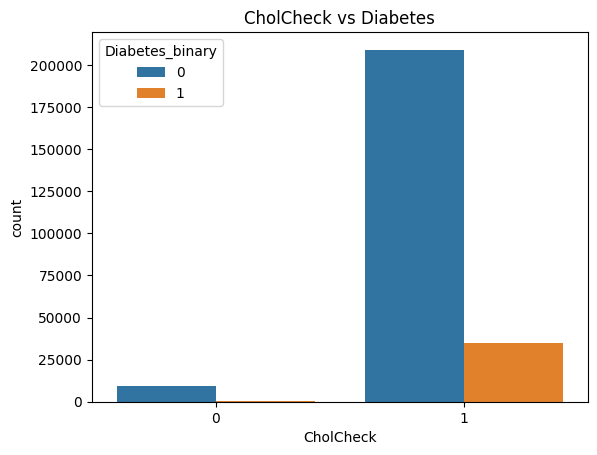

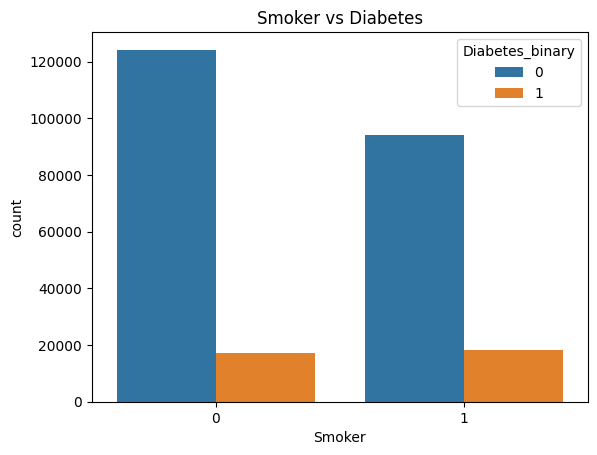

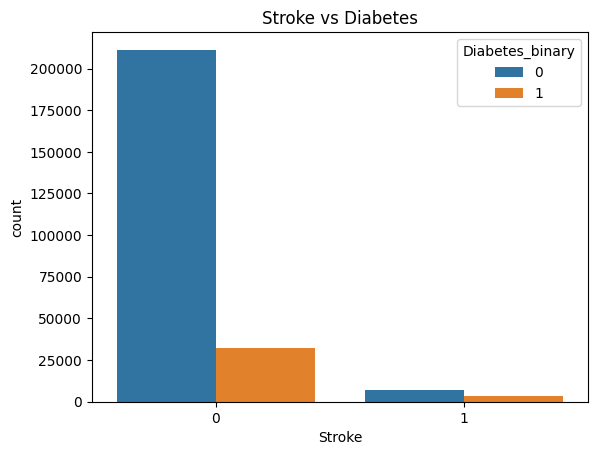

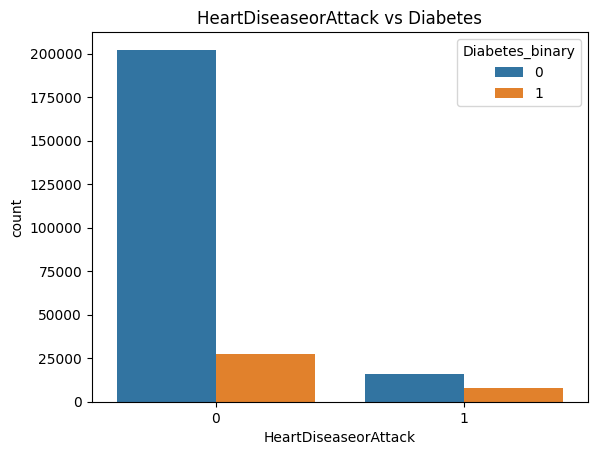

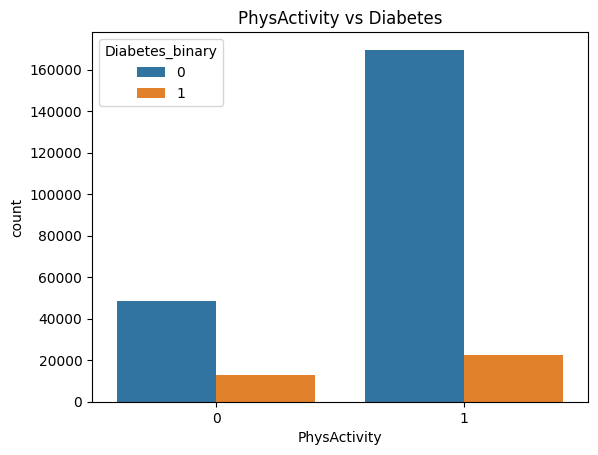

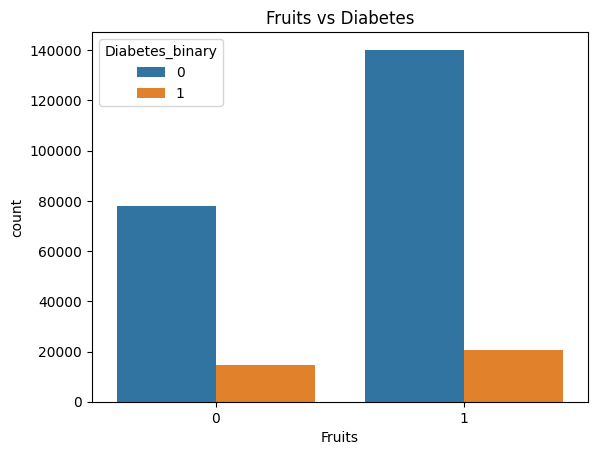

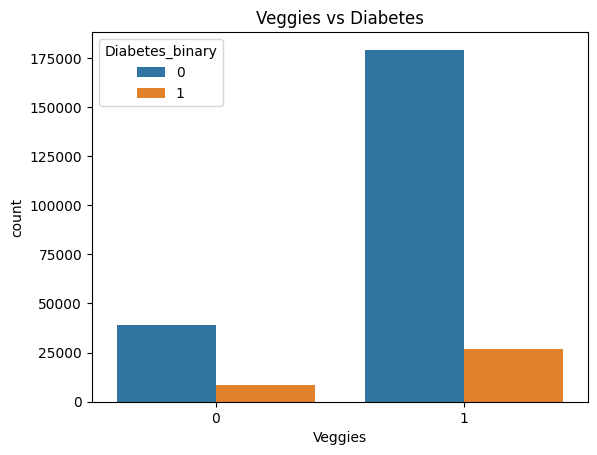

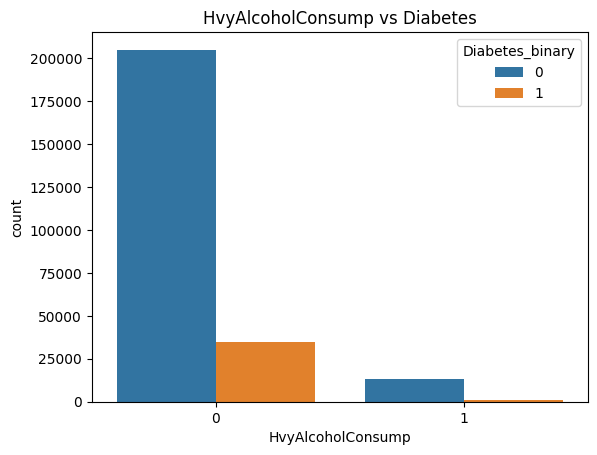

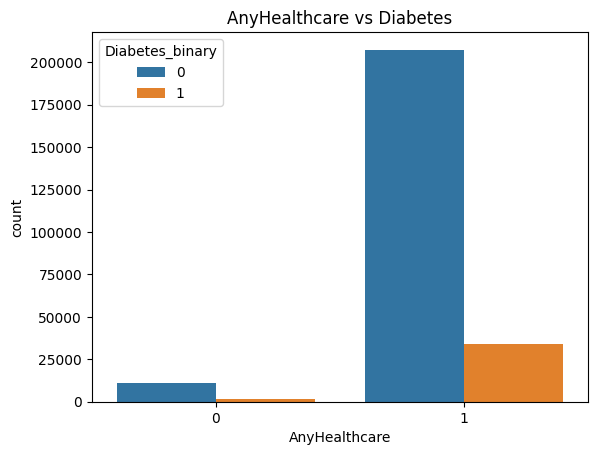

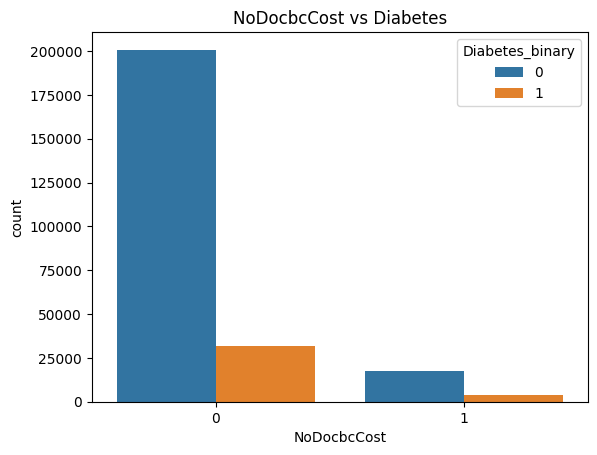

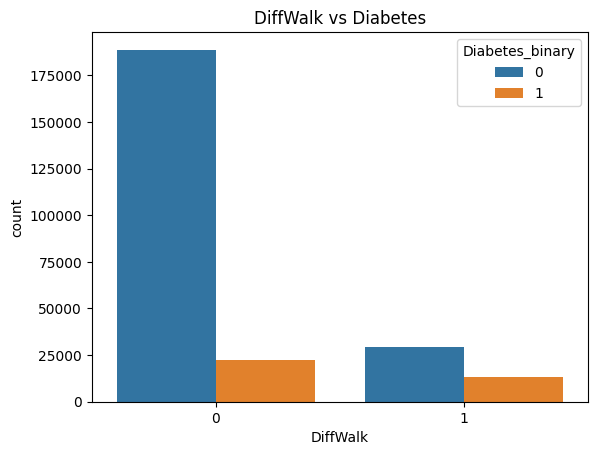

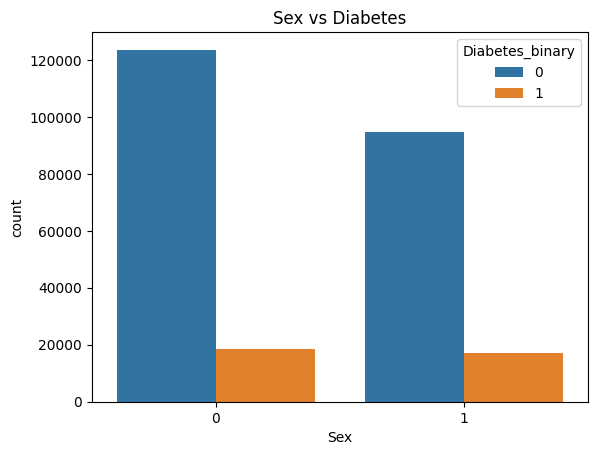

In [11]:

binary_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
               'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
               'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
               'DiffWalk', 'Sex']

for col in binary_cols:



    sns.countplot(data=df, x=col, hue='Diabetes_binary')
    plt.title(f'{col} vs Diabetes')
    plt.show()



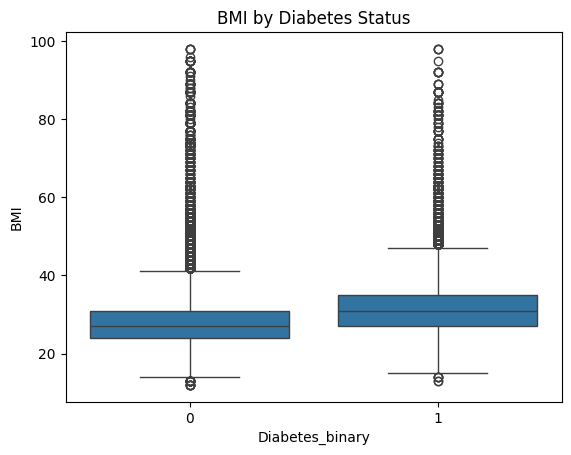

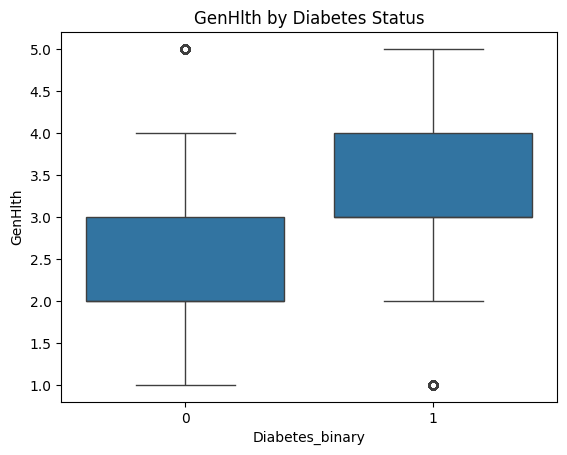

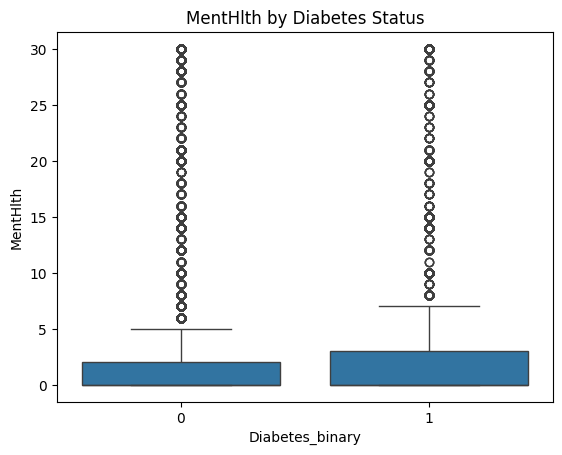

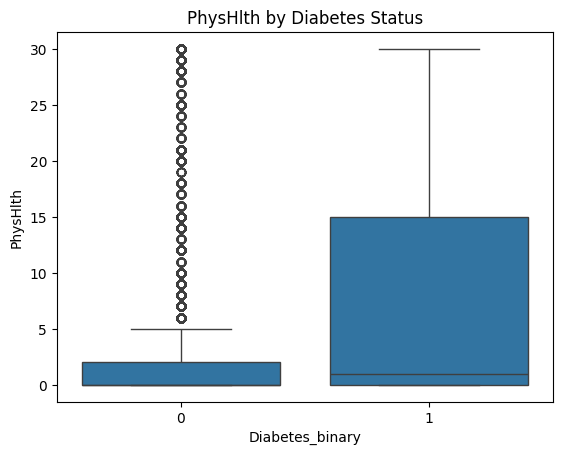

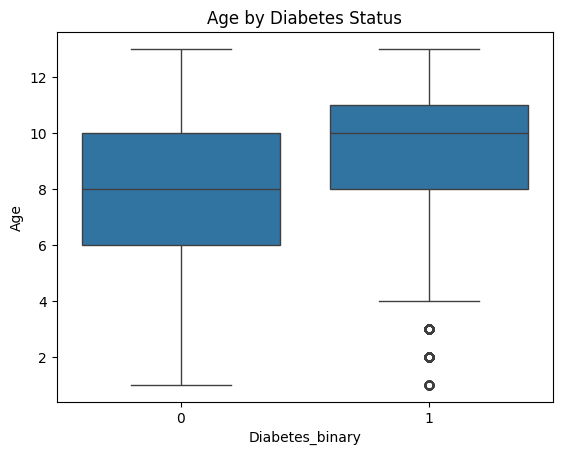

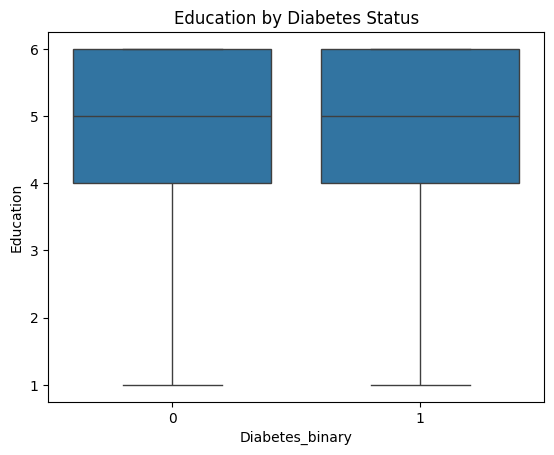

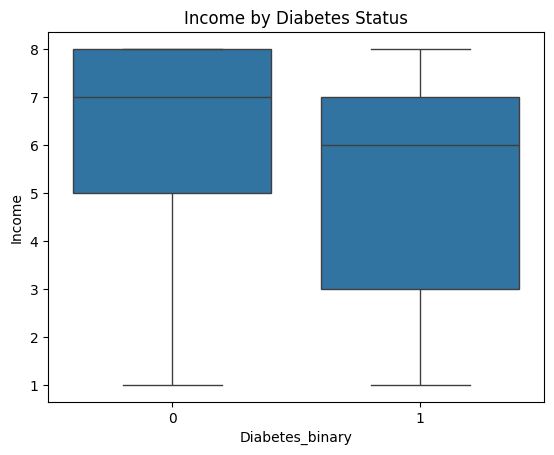

In [12]:
for col in continuous_cols:
    sns.boxplot(x='Diabetes_binary', y=col, data=df)
    plt.title(f'{col} by Diabetes Status')
    plt.show()

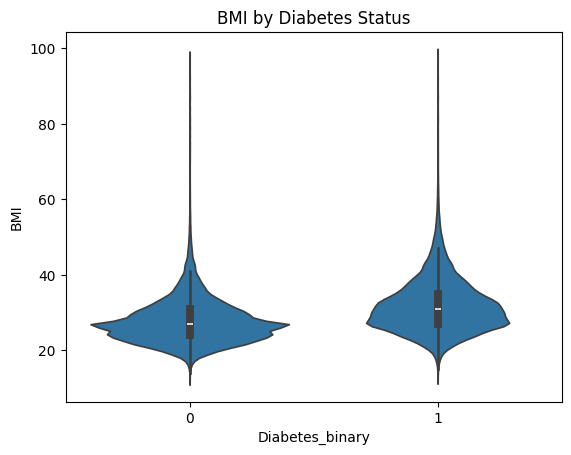

In [13]:
sns.violinplot(x='Diabetes_binary', y='BMI', data=df)
plt.title('BMI by Diabetes Status')
plt.show()


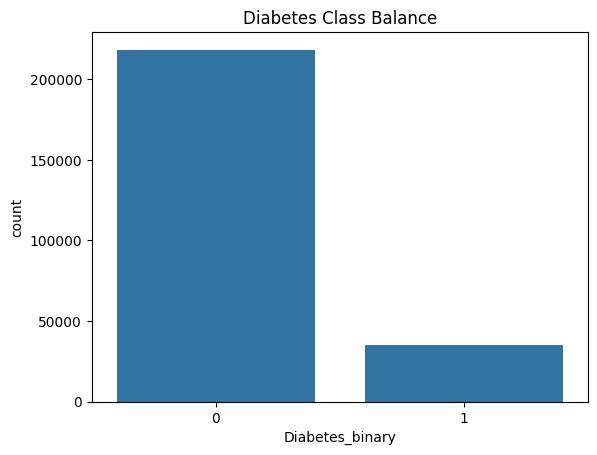

In [15]:
sns.countplot(x='Diabetes_binary', data=df)
plt.title("Diabetes Class Balance")
plt.show()

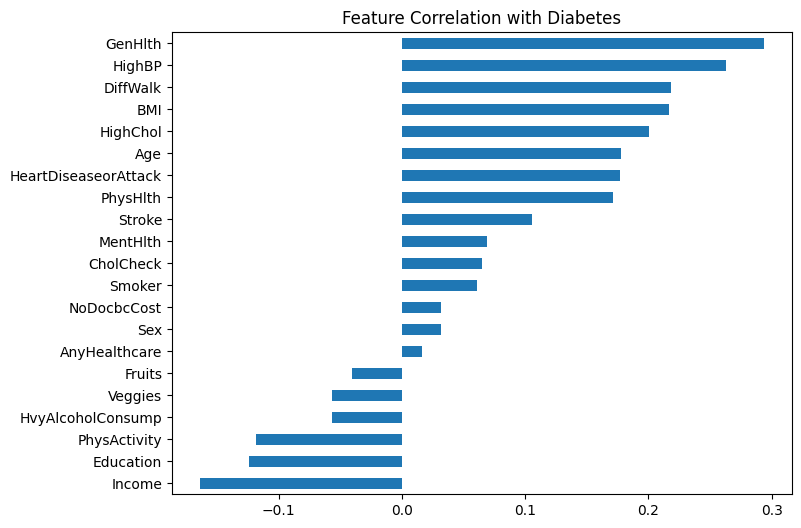

In [16]:
correlations = df.corr()['Diabetes_binary'].drop('Diabetes_binary')
correlations.sort_values().plot(kind='barh', figsize=(8, 6), title='Feature Correlation with Diabetes')
plt.show()

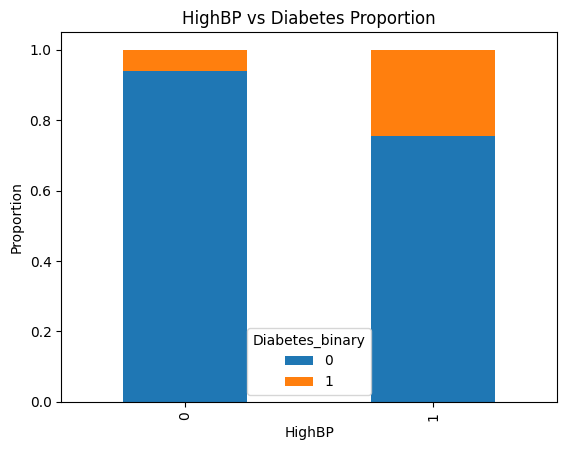

In [17]:
pd.crosstab(df['HighBP'], df['Diabetes_binary'], normalize='index').plot(kind='bar', stacked=True)
plt.title("HighBP vs Diabetes Proportion")
plt.ylabel("Proportion")
plt.show()

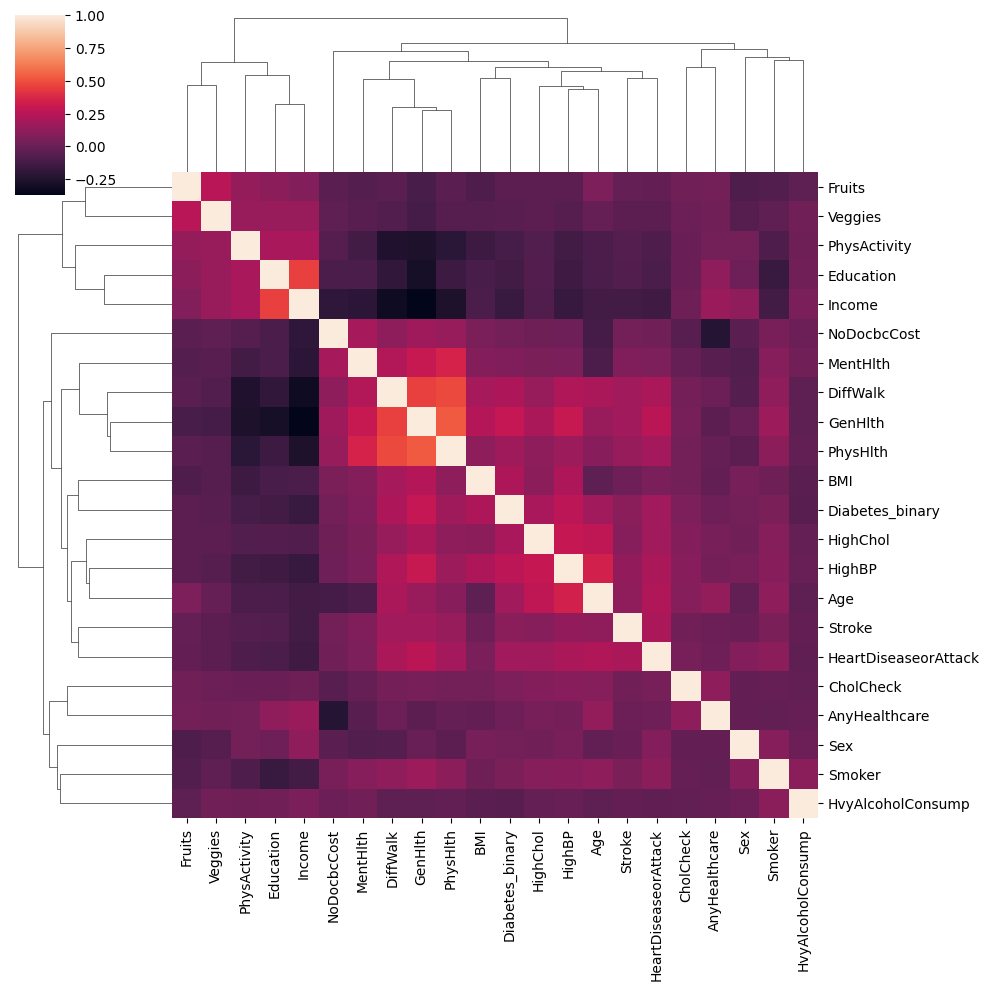

In [18]:
sns.clustermap(df.corr())
plt.show()

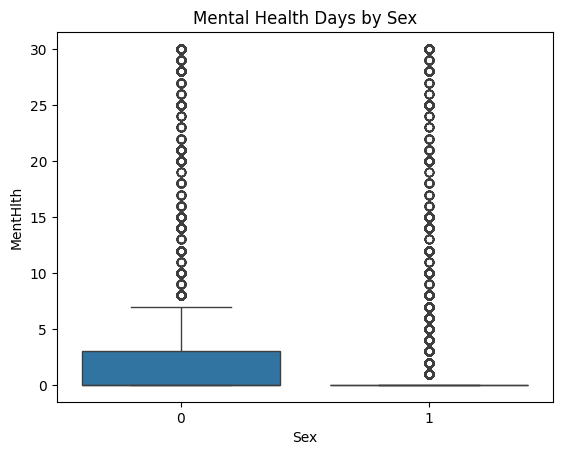

Sex
0    3.715434
1    2.510322
Name: MentHlth, dtype: float64

In [19]:
sns.boxplot(x='Sex', y='MentHlth', data=df)
plt.title('Mental Health Days by Sex')
plt.show()

df.groupby('Sex')['MentHlth'].mean()

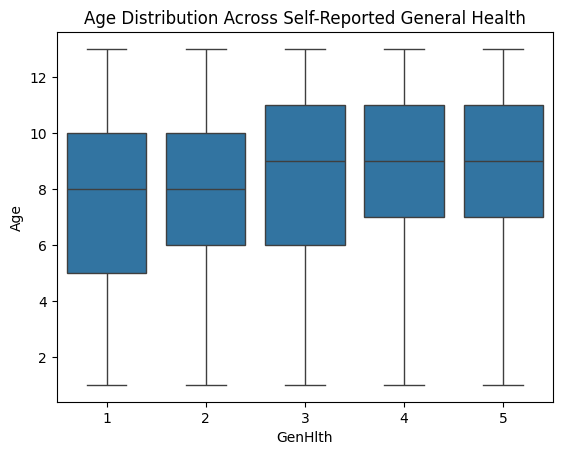

In [20]:
sns.boxplot(x='GenHlth', y='Age', data=df)
plt.title('Age Distribution Across Self-Reported General Health')
plt.show()

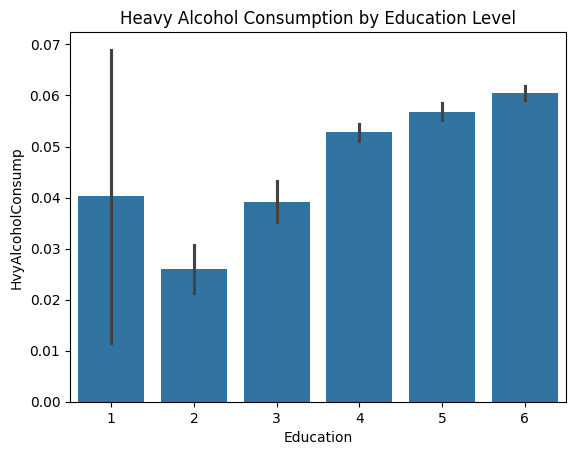

In [21]:
sns.barplot(x='Education', y='HvyAlcoholConsump', data=df)
plt.title('Heavy Alcohol Consumption by Education Level')
plt.show()

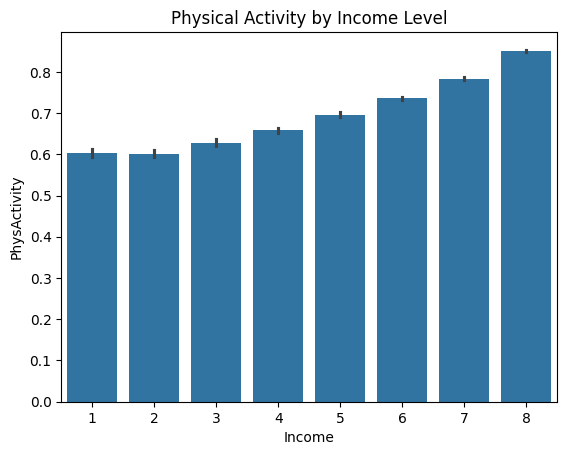

In [22]:
sns.barplot(x='Income', y='PhysActivity', data=df)
plt.title('Physical Activity by Income Level')
plt.show()

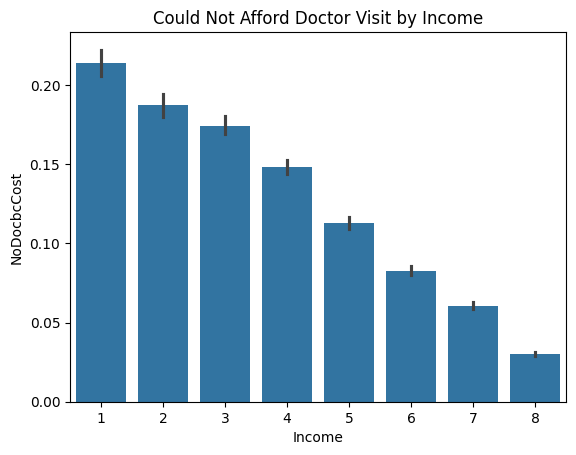

In [23]:
sns.barplot(x='Income', y='NoDocbcCost', data=df)
plt.title('Could Not Afford Doctor Visit by Income')
plt.show()

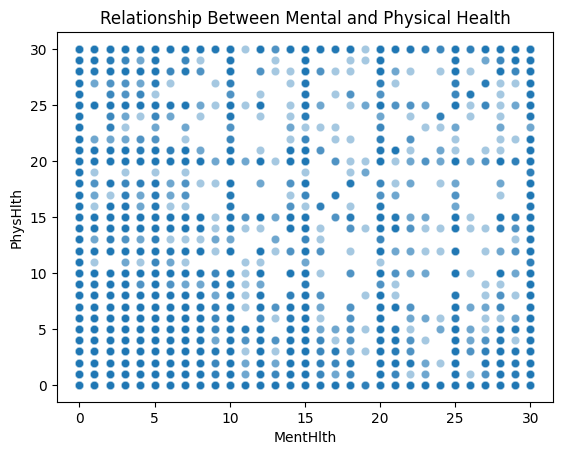

In [24]:
sns.scatterplot(x='MentHlth', y='PhysHlth', data=df, alpha=0.4)
plt.title('Relationship Between Mental and Physical Health')
plt.show()


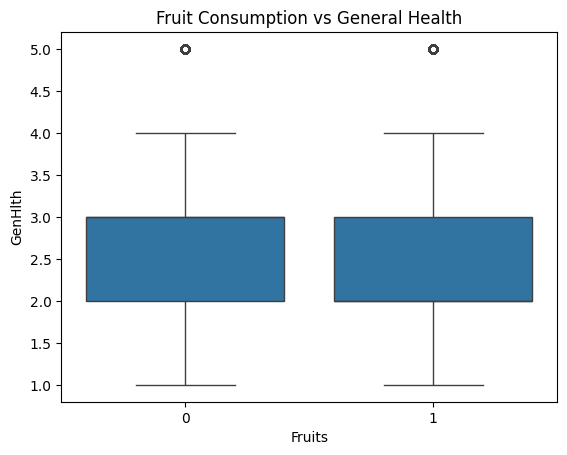

In [25]:
sns.boxplot(x='Fruits', y='GenHlth', data=df)
plt.title('Fruit Consumption vs General Health')
plt.show()


In [32]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [33]:
results = []

In [34]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    print(f"\n▶️ Training: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} - ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    # Results Summary
    print(classification_report(y_test, y_pred))
    print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(f"AUC Score: {roc_auc:.3f}")
    print(f"CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

    return {
        "Model": name,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc,
        "CV Accuracy Mean": cv_scores.mean(),
        "CV Accuracy Std": cv_scores.std()
    }


In [37]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=3
)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
print("Best AUC Score:", grid.best_score_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters: {'max_depth': 10, 'n_estimators': 200}
Best AUC Score: 0.8246857818001603



▶️ Training: Logistic Regression


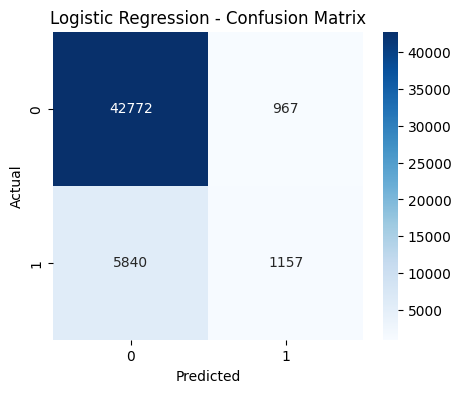

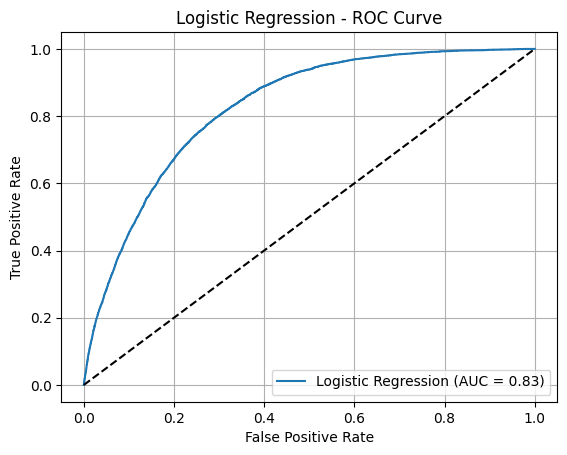

              precision    recall  f1-score   support

           0       0.88      0.98      0.93     43739
           1       0.54      0.17      0.25      6997

    accuracy                           0.87     50736
   macro avg       0.71      0.57      0.59     50736
weighted avg       0.83      0.87      0.83     50736

Test Accuracy: 0.866
AUC Score: 0.826
CV Accuracy: 0.863 ± 0.000


In [39]:
results.append(evaluate_model("Logistic Regression", LogisticRegression(max_iter=1000), X_train, y_train, X_test, y_test))


▶️ Training: Random Forest


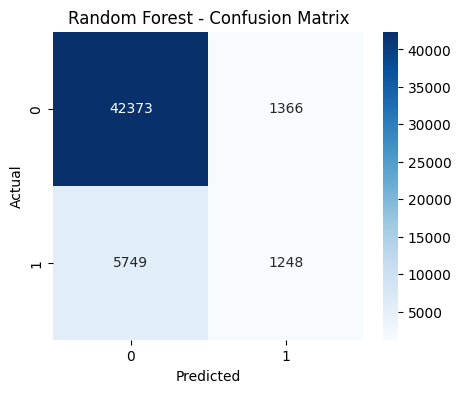

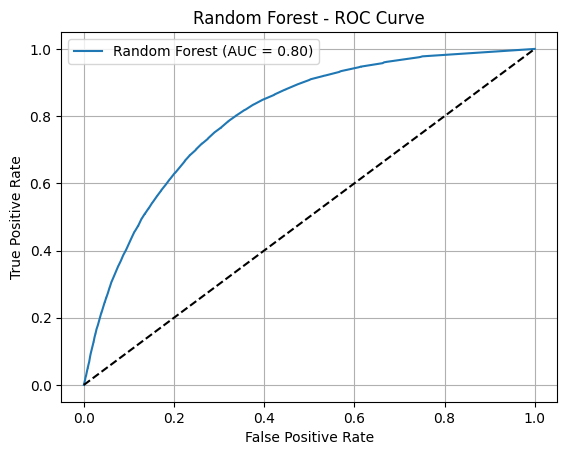

              precision    recall  f1-score   support

           0       0.88      0.97      0.92     43739
           1       0.48      0.18      0.26      6997

    accuracy                           0.86     50736
   macro avg       0.68      0.57      0.59     50736
weighted avg       0.82      0.86      0.83     50736

Test Accuracy: 0.860
AUC Score: 0.801
CV Accuracy: 0.859 ± 0.001


In [40]:
results.append(evaluate_model("Random Forest", RandomForestClassifier(), X_train, y_train, X_test, y_test))


▶️ Training: XGBoost


C:\Users\Maaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:11:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


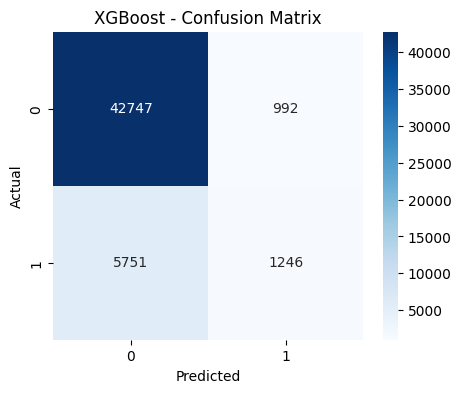

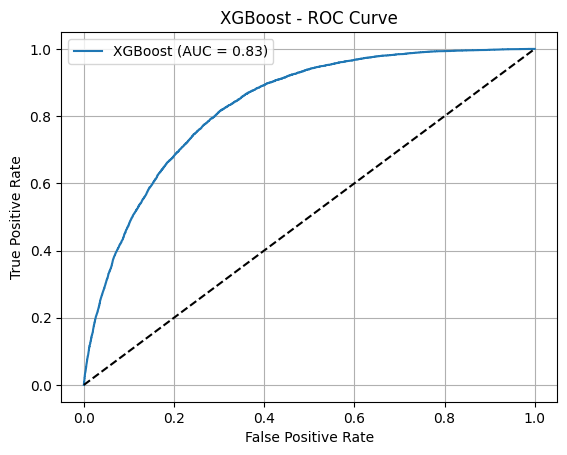

C:\Users\Maaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:11:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Maaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:11:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Maaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:11:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Maaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:11:57] WARNING: C:\actions-r

              precision    recall  f1-score   support

           0       0.88      0.98      0.93     43739
           1       0.56      0.18      0.27      6997

    accuracy                           0.87     50736
   macro avg       0.72      0.58      0.60     50736
weighted avg       0.84      0.87      0.84     50736

Test Accuracy: 0.867
AUC Score: 0.832
CV Accuracy: 0.865 ± 0.001


In [41]:
results.append(evaluate_model("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric='logloss'), X_train, y_train, X_test, y_test))

In [ ]:
results.append(evaluate_model("KNN", KNeighborsClassifier(n_neighbors=5,algorithm='auto',n_jobs=-1 ), X_train, y_train, X_test, y_test))


▶️ Training: MLP


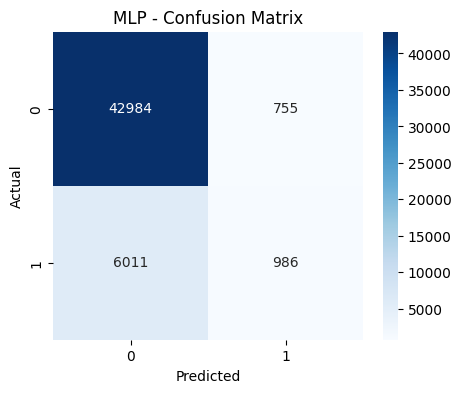

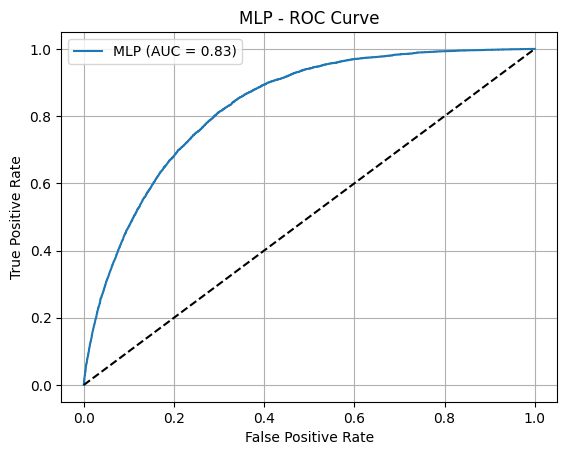

              precision    recall  f1-score   support

           0       0.88      0.98      0.93     43739
           1       0.57      0.14      0.23      6997

    accuracy                           0.87     50736
   macro avg       0.72      0.56      0.58     50736
weighted avg       0.83      0.87      0.83     50736

Test Accuracy: 0.867
AUC Score: 0.832
CV Accuracy: 0.866 ± 0.001
Model saved successfully!


In [43]:
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), early_stopping=True, max_iter=1000)
results.append(evaluate_model("MLP", mlp_model, X_train, y_train, X_test, y_test))
import joblib

joblib.dump(mlp_model, 'diabetes_model.pkl')
print("Model saved successfully!")

                 Model  Test Accuracy       AUC  CV Accuracy Mean  \
0  Logistic Regression       0.865835  0.826368          0.862928   
1        Random Forest       0.859764  0.800771          0.859326   
2              XGBoost       0.867096  0.831897          0.864844   
3                  MLP       0.866643  0.831553          0.865569   

   CV Accuracy Std  
0         0.000410  
1         0.000834  
2         0.000914  
3         0.000527  


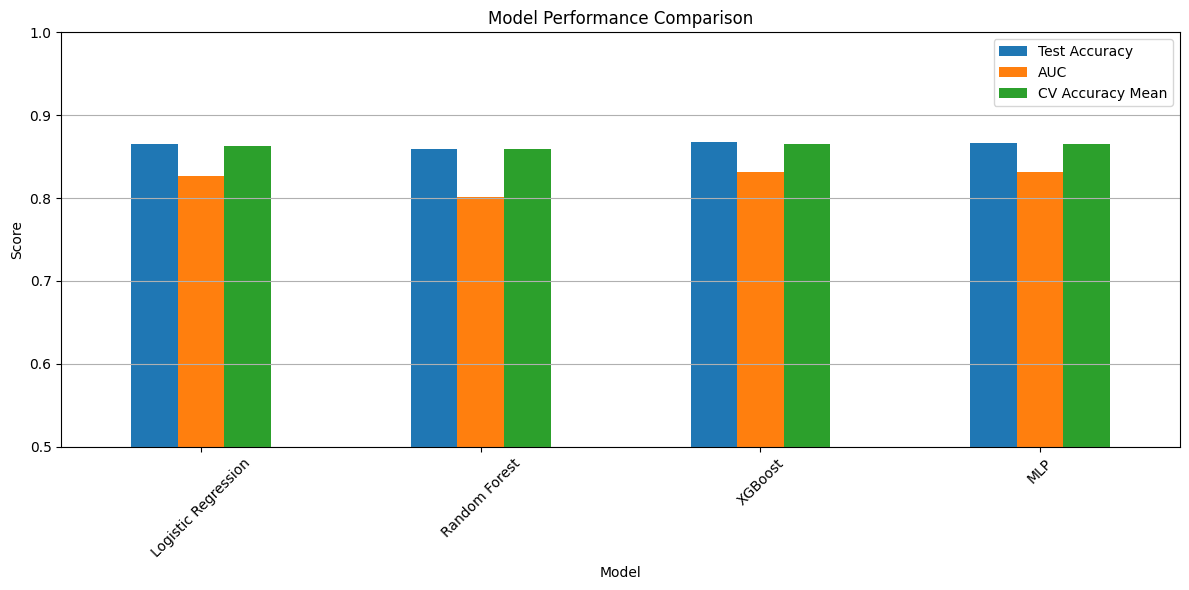

In [44]:
results_df = pd.DataFrame(results)
print(results_df)

# Bar Plot of AUC and Accuracy
results_df.set_index("Model")[["Test Accuracy", "AUC", "CV Accuracy Mean"]].plot(kind="bar", figsize=(12,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0.5, 1.0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [45]:
def plot_feature_importance(model, X_train, top_n=10):
    importances = model.feature_importances_
    indices = np.argsort(importances)[-top_n:][::-1]
    features = X_train.columns[indices]

    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances[indices], y=features)
    plt.title("Top Feature Importances")
    plt.xlabel("Importance")
    plt.show()


In [46]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="AUC", ascending=False)  # or 'Test Accuracy'
display(results_df)

,Model,Test Accuracy,AUC,CV Accuracy Mean,CV Accuracy Std
2,XGBoost,0.867096,0.831897,0.864844,0.000914
3,MLP,0.866643,0.831553,0.865569,0.000527
0,Logistic Regression,0.865835,0.826368,0.862928,0.000410
1,Random Forest,0.859764,0.800771,0.859326,0.000834


C:\Users\Maaz\AppData\Local\Temp\ipykernel_15780\43505058.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y=metric, palette="Set2")
C:\Users\Maaz\AppData\Local\Temp\ipykernel_15780\43505058.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y=metric, palette="Set2")
C:\Users\Maaz\AppData\Local\Temp\ipykernel_15780\43505058.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y=metric, palette="Set2")


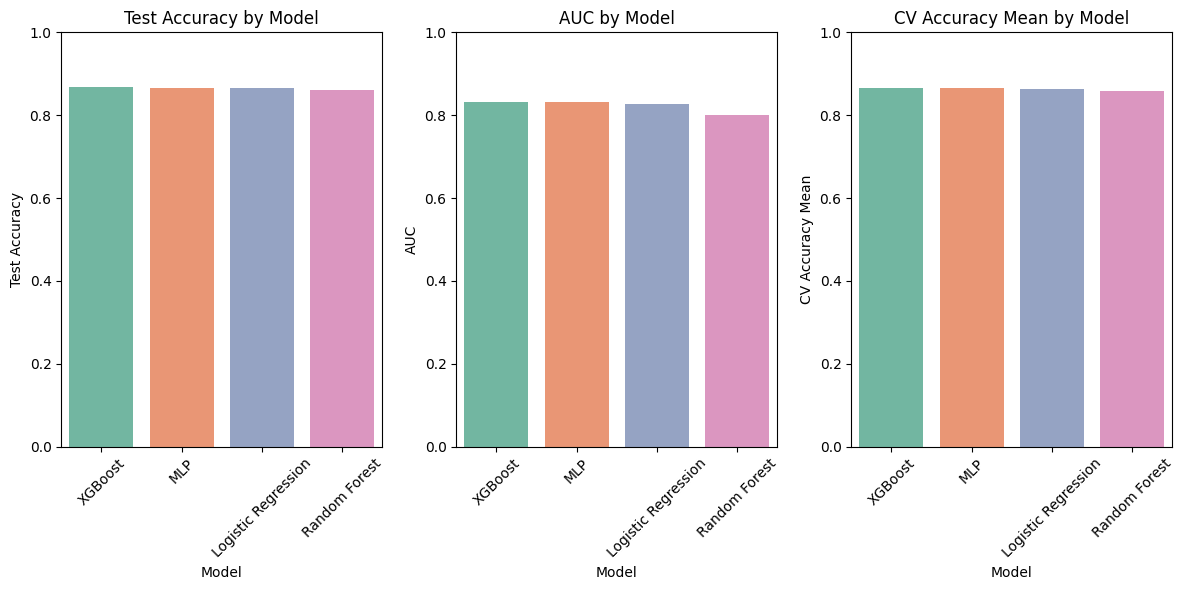

In [47]:
metrics = ["Test Accuracy", "AUC", "CV Accuracy Mean"]
plt.figure(figsize=(12, 6))
for i, metric in enumerate(metrics, 1):
    plt.subplot(1, 3, i)
    sns.barplot(data=results_df, x="Model", y=metric, palette="Set2")
    plt.title(f"{metric} by Model")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)

plt.tight_layout()
plt.show()


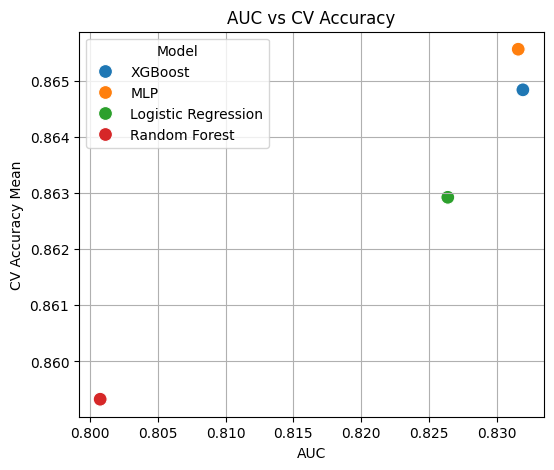

In [48]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=results_df, x="AUC", y="CV Accuracy Mean", hue="Model", s=100)
plt.title("AUC vs CV Accuracy")
plt.grid(True)
plt.show()


In [49]:
print("🔝 Best by AUC:", results_df.loc[results_df['AUC'].idxmax(), 'Model'])
print("🔝 Best by Test Accuracy:", results_df.loc[results_df['Test Accuracy'].idxmax(), 'Model'])
print("🔝 Most stable CV:", results_df.loc[results_df['CV Accuracy Std'].idxmin(), 'Model'])

🔝 Best by AUC: XGBoost
🔝 Best by Test Accuracy: XGBoost
🔝 Most stable CV: Logistic Regression


In [50]:
results_df.style.background_gradient(subset=["AUC", "Test Accuracy", "CV Accuracy Mean"], cmap="Greens")

,Model,Test Accuracy,AUC,CV Accuracy Mean,CV Accuracy Std
2,XGBoost,0.867096,0.831897,0.864844,0.000914
3,MLP,0.866643,0.831553,0.865569,0.000527
0,Logistic Regression,0.865835,0.826368,0.862928,0.000410
1,Random Forest,0.859764,0.800771,0.859326,0.000834


In [52]:
import sys
!{sys.executable} -m pip install gradio

  Using cached gradio-6.19.0-py3-none-any.whl.metadata (17 kB)
  Using cached audioop_lts-0.2.2-cp313-abi3-win_amd64.whl.metadata (2.0 kB)
  Using cached fastapi-0.138.0-py3-none-any.whl.metadata (27 kB)
  Using cached gradio_client-2.5.0-py3-none-any.whl.metadata (7.1 kB)
  Using cached groovy-0.1.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached hf_gradio-0.4.1-py3-none-any.whl.metadata (428 bytes)
  Using cached huggingface_hub-1.21.0-py3-none-any.whl.metadata (14 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached pydub-0.25.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached python_multipart-0.0.32-py3-none-any.whl.metadata (2.1 kB)
  Using cached safehttpx-0.1.7-py3-none-any.whl.metadata (4.2 kB)
  Using cached semantic_version-2.10.0-py2.py3-none-any.whl.metadata (9.7 kB)
  Using cached starlette-1.3.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached tomlkit-0.14.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached typer-0.26.7-py3-none-any

In [53]:
import gradio as gr

try:
    model = joblib.load('diabetes_model.pkl')
except FileNotFoundError:
    # Fallback option: If you haven't run the cell to save your model yet, 
    # you can temporarily assign your active model variable here:
    # model = best_model
    print("Please make sure 'diabetes_model.pkl' exists or link your active model variable.")

# 3. Create the prediction function
def predict_diabetes(
    HighBP, HighChol, CholCheck, BMI, Smoker, Stroke, HeartDiseaseorAttack, 
    PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, 
    GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, Education, Income
):
    # Convert string inputs back into the numerical formats expected by the model
    sex_val = 1 if Sex == "Male" else 0
    high_bp = 1 if HighBP == "Yes" else 0
    high_chol = 1 if HighChol == "Yes" else 0
    chol_check = 1 if CholCheck == "Yes (within 5 years)" else 0
    smoker_val = 1 if Smoker == "Yes (>=100 cigarettes)" else 0
    stroke_val = 1 if Stroke == "Yes" else 0
    hd_val = 1 if HeartDiseaseorAttack == "Yes" else 0
    phys_act = 1 if PhysActivity == "Yes" else 0
    fruits_val = 1 if Fruits == "Yes (1+ day)" else 0
    veggies_val = 1 if Veggies == "Yes (1+ day)" else 0
    alcohol = 1 if HvyAlcoholConsump == "Yes" else 0
    healthcare = 1 if AnyHealthcare == "Yes" else 0
    nodoc = 1 if NoDocbcCost == "Yes" else 0
    diff_walk = 1 if DiffWalk == "Yes" else 0

    # Arrange input features in the exact columns array structure your model trained on
    input_data = np.array([[
        high_bp, high_chol, chol_check, float(BMI), smoker_val, stroke_val, hd_val,
        phys_act, fruits_val, veggies_val, alcohol, healthcare, nodoc, 
        float(GenHlth), float(MentHlth), float(PhysHlth), diff_walk, sex_val, 
        float(Age), float(Education), float(Income)
    ]])

    # Make the prediction
    prediction = model.predict(input_data)[0]
    
    # If your model supports predict_proba, get confidence rates
    try:
        probabilities = model.predict_proba(input_data)[0]
        confidence = f" (Confidence: {probabilities[int(prediction)]*100:.1f}%)"
    except:
        confidence = ""

    # Return a reader-friendly statement
    if prediction == 1:
        return f"🚨 High Risk: Prediabetes or Diabetes indicated.{confidence}"
    else:
        return f"✅ Low Risk: Healthy / No Diabetes indicated.{confidence}"

# 4. Design the User Interface layouts
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🩺 CDC Diabetes Risk Predictor Portal")
    gr.Markdown("Input patient demographics, health history, and behaviors to estimate diabetes risk classification.")
    
    with gr.Row():
        with gr.Column():
            gr.Markdown("### 👤 Demographics & Social Factors")
            sex = gr.Radio(["Female", "Male"], label="Sex")
            age = gr.Slider(1, 13, step=1, value=5, label="Age Bracket (1-13 Scale)")
            education = gr.Slider(1, 6, step=1, value=4, label="Education Level (1-6 Scale)")
            income = gr.Slider(1, 8, step=1, value=5, label="Income Bracket (1-8 Scale)")
            
            gr.Markdown("### 🏥 Medical History Indicators")
            high_bp = gr.Radio(["No", "Yes"], label="High Blood Pressure History")
            high_chol = gr.Radio(["No", "Yes"], label="High Cholesterol History")
            chol_check = gr.Radio(["No (None in 5 years)", "Yes (within 5 years)"], label="Cholesterol Check History")
            stroke = gr.Radio(["No", "Yes"], label="Ever suffered a Stroke?")
            heart_disease = gr.Radio(["No", "Yes"], label="Coronary Heart Disease or Heart Attack history?")
            
        with gr.Column():
            gr.Markdown("### 📐 Health States")
            bmi = gr.Number(value=25, label="Body Mass Index (BMI)")
            gen_hlth = gr.Slider(1, 5, step=1, value=3, label="General Health Rating (1=Excellent, 5=Poor)")
            ment_hlth = gr.Slider(0, 30, step=1, value=0, label="Bad Mental Health Days (Past 30 days)")
            phys_hlth = gr.Slider(0, 30, step=1, value=0, label="Ill Physical Health Days (Past 30 days)")
            diff_walk = gr.Radio(["No", "Yes"], label="Serious difficulty walking/climbing stairs?")

            gr.Markdown("### 🍏 Lifestyle Behaviors")
            smoker = gr.Radio(["No", "Yes"], label="Smoker (At least 100 cigarettes lifetime)")
            phys_activity = gr.Radio(["No", "Yes"], label="Physical Activity (Past 30 days)")
            fruits = gr.Radio(["No", "Yes (1+ day)"], label="Consumes Fruits daily?")
            veggies = gr.Radio(["No", "Yes (1+ day)"], label="Consumes Vegetables daily?")
            alcohol = gr.Radio(["No", "Yes"], label="Heavy Alcohol Consumption?")
            
            gr.Markdown("### 💳 Healthcare Access")
            healthcare = gr.Radio(["No", "Yes"], label="Has Health Insurance coverage?")
            nodoc = gr.Radio(["No", "Yes"], label="Skipped Doctor appointments due to Cost?")

    btn = gr.Button("Evaluate Diabetes Risk Status", variant="primary")
    output = gr.Textbox(label="Model Predictive Output Assessment Result")

    # Link inputs array matching function args sequence
    btn.click(
        fn=predict_diabetes,
        inputs=[
            high_bp, high_chol, chol_check, bmi, smoker, stroke, heart_disease,
            phys_activity, fruits, veggies, alcohol, healthcare, nodoc,
            gen_hlth, ment_hlth, phys_hlth, diff_walk, sex, age, education, income
        ],
        outputs=output
    )

# 5. Launch the Web Interface App
demo.launch(share=True)

C:\Users\Maaz\AppData\Local\Temp\ipykernel_15780\1685595541.py:58: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


2026/06/25 19:34:03 [W] [service.go:132] login to server failed: dial tcp: lookup gradio-live.com: getaddrinfow: This is usually a temporary error during hostname resolution and means that the local server did not receive a response from an authoritative server.


C:\Users\Maaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
C:\Users\Maaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
C:\Users\Maaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
C:\Users\Maaz\AppData\Local\Programs\Python\Python313\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
C:\Users